In [70]:
from dotenv import load_dotenv
load_dotenv()

True

In [71]:
# State 정의 

from typing import TypedDict,Literal, NotRequired

class TeacherState(TypedDict):
    user_input: str   # 사용자 입력
    sentiment: NotRequired[Literal['positive', 'negative', 'aggresive']]   # 감정 분석
    core_msg: NotRequired[str] # 핵심 메세지
    warning_count:  NotRequired[int] # 경고 횟수
    response: NotRequired[str]     # 최종 답변

# {'user_input':  , }

In [72]:
from langchain.chat_models import init_chat_model

llm = init_chat_model('gpt-4o-mini')


# 감정 분석 Node
def analyze_sentiment(state: TeacherState):
    prompt=f'''
    아래 문장의 감정을 분류.
    아래 3가지 단어 중 1가지 단어로 판단
    positive
    negative
    aggresive
    결과값은 positive, negative, aggresive로만 나타내야해
    문장 : {state['user_input']}
    '''
    result = llm.invoke(prompt)
    return {'sentiment':result.content} # 바뀐 부분만 return

In [73]:
# 나머지 노드

import random

def positive_node(state: TeacherState):
    msgs = ['최고', '멋져', '훌륭']
    keyword = random.choice(msgs)
    return {'core_msg': keyword}

def negative_node(state: TeacherState):
    msgs = ['힘내', '위로', '괜찮아']
    keyword = random.choice(msgs)
    return {'core_msg': keyword}

def aggresive_node(state: TeacherState):
    # dict.get(a, b) -> key a가 있으면, 해당 value. key a 가 없으면 b가 나옴
    # state.get['warning_count']+=1 -> 이거는 warning_count가 없으면 에러남 (즉, invoke 시 무조건 warning_count 값을 넣어줘야 작동함)
    count = state.get('warning_count',0) + 1
    return {'warning_count': count,'core_msg': '공격적인 표현은 삼가해주세요'}

In [74]:
x ={'a': 1, 'b': 2}
x.get('c',0)
x['a']

1

In [75]:
def block_user_node(state: TeacherState):
    state['warning_count']+=1
    return {'warning_count':state['warning_count'],'response':' 차단됨'}

In [76]:
# 완성 Node

def make_final_message(state: TeacherState):
    prompt = f''' 
    다음 사용자 입력에 맞는 답변을 생성해.
    핵심 키워드/메시지를 참조해야해.

    사용자 입력: {state['user_input']}
    핵심 키워드: {state['core_msg']}
    '''
    result = llm.invoke(prompt)
    return {'response': result.content}

In [77]:
# 감정 분석 노드 라우터 
def router(state: TeacherState):
    return state['sentiment'] 

# def router_aggresive(state: TeacherState):
#     if state['warning_count'] < 3:
#         result = 'Go warning < 3'
#     else:
#         result = 'block warning >= 3'
#     return result

def block_before(state: TeacherState):
    count = state.get('warning_count',0)
    if count < 3:
        result = '다음 진행'
    else: 
        result ='바로 차단'
        
    return result

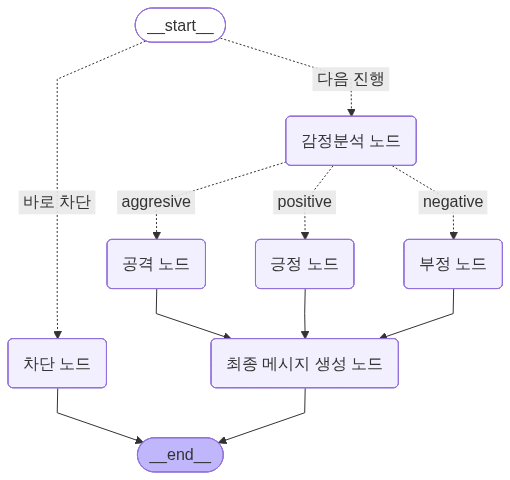

In [78]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(TeacherState)

# 노드 등록
graph.add_node('감정분석 노드',analyze_sentiment)
graph.add_node('긍정 노드', positive_node)
graph.add_node('부정 노드', negative_node)
graph.add_node('공격 노드', aggresive_node)
graph.add_node('차단 노드', block_user_node)
graph.add_node('최종 메시지 생성 노드',make_final_message)

# 엣지 등록
graph.add_conditional_edges(START, block_before, {'다음 진행': '감정분석 노드','바로 차단': '차단 노드'})
graph.add_conditional_edges('감정분석 노드', router, {'positive': '긍정 노드','negative': '부정 노드','aggresive': '공격 노드'})
graph.add_edge('긍정 노드', '최종 메시지 생성 노드')
graph.add_edge('부정 노드', '최종 메시지 생성 노드')
graph.add_edge('공격 노드', '최종 메시지 생성 노드')

graph.add_edge('최종 메시지 생성 노드',END)
graph.add_edge('차단 노드',END)
app = graph.compile()
app

In [79]:
app.invoke({'user_input': '죽을래?', 'warning_count': 0})   # 답변 정상

{'user_input': '죽을래?',
 'sentiment': 'aggresive',
 'core_msg': '공격적인 표현은 삼가해주세요',
 'warning_count': 1,
 'response': '공격적인 표현은 삼가해 주시면 좋겠습니다. 서로 긍정적인 대화를 나눌 수 있도록 해요. 어떤 다른 이야기로 대화를 이어갈까요?'}

In [80]:
result = app.invoke({'user_input': '기분이 좋아', 'warning_count': 3})  # 답변 정상
print(result['response'])
print(result['warning_count'])

 차단됨
4


In [ ]:
result = app.invoke({'user_input': '죽을래?', 'warning_count': 3})  # 차단
print(result['response'])
print(result['warning_count'])




 차단됨
4
